In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
%cd /kaggle/working

!test -d AnomalyDINO || git clone \
  https://github.com/dammsi/AnomalyDINO.git

%cd /kaggle/working/AnomalyDINO

!git checkout b9d1c2648e3a5247437d4d953d907a8f3d994457

import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import torch
import torchvision
import scipy
import sklearn
import matplotlib
from PIL import Image

DATA_ROOT = Path(
    "/kaggle/input/datasets/neelu1/"
    "thermal-anomaly-detection-dataset/"
    "harbor_anomaly_dataset"
)

commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    text=True,
).strip()

print("Commit AnomalyDINO:", commit)
print("Dataset presente:", DATA_ROOT.exists())
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Scikit-learn:", sklearn.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", [
    torch.cuda.get_device_name(i)
    for i in range(torch.cuda.device_count())
])

/kaggle/working
Cloning into 'AnomalyDINO'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 137 (delta 41), reused 31 (delta 31), pack-reused 86 (from 1)
Receiving objects: 100% (137/137), 6.87 MiB | 28.24 MiB/s, done.
Resolving deltas: 100% (76/76), done.
/kaggle/working/AnomalyDINO
Note: switching to 'b9d1c2648e3a5247437d4d953d907a8f3d994457'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at b9d1c26 minor upd

In [4]:
from pathlib import Path

print("Contenuto /kaggle/input:")
for path in Path("/kaggle/input").rglob("harbor_anomaly_dataset"):
    print(path)

print("\nPrime cartelle disponibili:")
for path in list(Path("/kaggle/input").rglob("*"))[:40]:
    print(path)

Contenuto /kaggle/input:
/kaggle/input/datasets/neelu1/thermal-anomaly-detection-dataset/harbor_anomaly_dataset

Prime cartelle disponibili:
/kaggle/input/datasets
/kaggle/input/datasets/neelu1
/kaggle/input/datasets/neelu1/thermal-anomaly-detection-dataset
/kaggle/input/datasets/neelu1/thermal-anomaly-detection-dataset/harbor_anomaly_dataset
/kaggle/input/datasets/neelu1/thermal-anomaly-detection-dataset/harbor_anomaly_dataset/visualization_anomalies
/kaggle/input/datasets/neelu1/thermal-anomaly-detection-dataset/harbor_anomaly_dataset/test_annotations_anomalies
/kaggle/input/datasets/neelu1/thermal-anomaly-detection-dataset/harbor_anomaly_dataset/test
/kaggle/input/datasets/neelu1/thermal-anomaly-detection-dataset/harbor_anomaly_dataset/train
/kaggle/input/datasets/neelu1/thermal-anomaly-detection-dataset/harbor_anomaly_dataset/visualization_anomalies/Thermal_dataset_anomalies.png
/kaggle/input/datasets/neelu1/thermal-anomaly-detection-dataset/harbor_anomaly_dataset/test_annotations_

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd

dataset_candidates = list(
    Path("/kaggle/input").rglob("harbor_anomaly_dataset")
)

assert dataset_candidates, "Dataset non trovato"

DATA_ROOT = dataset_candidates[0]
WORK = Path("/kaggle/working")

print("Dataset:", DATA_ROOT)

# Individua i 300 clip normali
train_clip_dirs = sorted({
    path.parent
    for path in (DATA_ROOT / "train").rglob("*.jpg")
})

assert len(train_clip_dirs) == 300

# Split riproducibile per clip:
# 200 disponibili come riferimenti, 100 solo per calibrazione
SEED = 20260705
rng = np.random.default_rng(SEED)
permutation = rng.permutation(len(train_clip_dirs))

reference_clip_dirs = [
    train_clip_dirs[index]
    for index in permutation[:200]
]

calibration_clip_dirs = [
    train_clip_dirs[index]
    for index in permutation[200:]
]

reference_rows = []

for rank, clip_dir in enumerate(reference_clip_dirs, start=1):
    frames = sorted(clip_dir.glob("*.jpg"))
    selected_frame = frames[len(frames) // 2]
    relative = clip_dir.relative_to(DATA_ROOT / "train")

    reference_rows.append({
        "reference_rank": rank,
        "date": relative.parts[-2],
        "clip": relative.parts[-1],
        "path": str(selected_frame),
        "included_16_shot": rank <= 16,
        "included_64_shot": rank <= 64,
        "included_200_shot": rank <= 200,
    })

reference_manifest = pd.DataFrame(reference_rows)

calibration_rows = []

for clip_dir in calibration_clip_dirs:
    frames = sorted(clip_dir.glob("*.jpg"))
    selected_frame = frames[len(frames) // 2]
    relative = clip_dir.relative_to(DATA_ROOT / "train")

    calibration_rows.append({
        "date": relative.parts[-2],
        "clip": relative.parts[-1],
        "path": str(selected_frame),
    })

calibration_manifest = pd.DataFrame(calibration_rows)

# Manifest completo del test
test_rows = []

for annotation_path in sorted(
    (DATA_ROOT / "test_annotations_anomalies").rglob("*.npy")
):
    date = annotation_path.parent.name
    clip = annotation_path.stem

    labels = np.load(
        annotation_path,
        allow_pickle=False,
    ).reshape(-1)

    frames = sorted(
        (DATA_ROOT / "test" / date / clip).glob("*.jpg")
    )

    for frame_index, (frame_path, label) in enumerate(
        zip(frames, labels)
    ):
        test_rows.append({
            "date": date,
            "clip": clip,
            "frame_index": frame_index,
            "path": str(frame_path),
            "label": int(label != 0),
        })

test_manifest = pd.DataFrame(test_rows)

reference_manifest.to_csv(
    WORK / "E08_reference_manifest.csv",
    index=False,
)
calibration_manifest.to_csv(
    WORK / "E08_calibration_manifest.csv",
    index=False,
)
test_manifest.to_csv(
    WORK / "E08_test_manifest.csv",
    index=False,
)

print("Riferimenti disponibili:", len(reference_manifest))
print("Clip calibrazione:", len(calibration_manifest))
print("Test:", len(test_manifest))
print(test_manifest["label"].value_counts().sort_index())
display(reference_manifest.head(16))

Dataset: /kaggle/input/datasets/neelu1/thermal-anomaly-detection-dataset/harbor_anomaly_dataset
Riferimenti disponibili: 200
Clip calibrazione: 100
Test: 3509
label
0    2385
1    1124
Name: count, dtype: int64


,reference_rank,date,clip,path,included_16_shot,included_64_shot,included_200_shot
0,1,20200818,clip_19_1835,/kaggle/input/datasets/neelu1/thermal-anomaly-...,True,True,True
1,2,20200820,clip_28_1303,/kaggle/input/datasets/neelu1/thermal-anomaly-...,True,True,True
2,3,20200823,clip_12_0508,/kaggle/input/datasets/neelu1/thermal-anomaly-...,True,True,True
3,4,20200820,clip_46_2054,/kaggle/input/datasets/neelu1/thermal-anomaly-...,True,True,True
4,5,20200822,clip_8_0323,/kaggle/input/datasets/neelu1/thermal-anomaly-...,True,True,True
5,6,20200823,clip_10_0412,/kaggle/input/datasets/neelu1/thermal-anomaly-...,True,True,True
6,7,20200817,clip_4_1133,/kaggle/input/datasets/neelu1/thermal-anomaly-...,True,True,True
7,8,20200819,clip_30_1357,/kaggle/input/datasets/neelu1/thermal-anomaly-...,True,True,True
8,9,20200822,clip_38_1703,/kaggle/input/datasets/neelu1/thermal-anomaly-...,True,True,True
9,10,20200820,clip_27_1235,/kaggle/input/datasets/neelu1/thermal-anomaly-...,True,True,True


In [6]:
%cd /kaggle/working/AnomalyDINO

import sys
import subprocess
import hashlib
import torch

sys.path.insert(0, "/kaggle/working/AnomalyDINO")

from src.backbones import get_model

MODEL_NAME = "dinov2_vits14"
RESOLUTION = 448
DEVICE = "cuda:0"

dinov2_remote_commit = subprocess.check_output(
    [
        "git",
        "ls-remote",
        "https://github.com/facebookresearch/dinov2.git",
        "HEAD",
    ],
    text=True,
).split()[0]

model = get_model(
    MODEL_NAME,
    DEVICE,
    smaller_edge_size=RESOLUTION,
)

sample_path = reference_manifest.iloc[0]["path"]
sample_tensor, sample_grid = model.prepare_image(sample_path)
sample_features = model.extract_features(sample_tensor)

print("Modello:", MODEL_NAME)
print("Risoluzione lato corto:", RESOLUTION)
print("Patch size:", model.model.patch_size)
print("Griglia campione:", sample_grid)
print("Forma feature:", sample_features.shape)
print("Commit DINOv2 remoto:", dinov2_remote_commit)
print("GPU:", torch.cuda.get_device_name(0))

/kaggle/working/AnomalyDINO
Loading model: dinov2_vits14
Device: cuda:0
Smaller edge size: 448
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 280MB/s]


Modello: dinov2_vits14
Risoluzione lato corto: 448
Patch size: 14
Griglia campione: (32, 42)
Forma feature: (1344, 384)
Commit DINOv2 remoto: 7764ea0f912e53c92e82eb78a2a1631e92725fc8
GPU: Tesla T4


In [7]:
import time
import hashlib
import numpy as np
import torch.nn.functional as F
from tqdm.auto import tqdm
from pathlib import Path

reference_feature_blocks = []
patch_counts = []

memory_start = time.time()

for _, row in tqdm(
    reference_manifest.iterrows(),
    total=len(reference_manifest),
    desc="Estrazione riferimenti normali",
):
    image_tensor, grid_size = model.prepare_image(
        row["path"]
    )
    features = model.extract_features(
        image_tensor
    ).astype(np.float32)

    reference_feature_blocks.append(features)
    patch_counts.append(len(features))

reference_features = np.concatenate(
    reference_feature_blocks,
    axis=0,
)

normal_memory = torch.from_numpy(
    reference_features
).to(DEVICE)

normal_memory = F.normalize(
    normal_memory,
    p=2,
    dim=1,
)

normal_memory_transposed = normal_memory.T.contiguous()

cumulative_patches = np.cumsum(patch_counts)

memory_cutoffs = {
    16: int(cumulative_patches[15]),
    64: int(cumulative_patches[63]),
    200: int(cumulative_patches[199]),
}

memory_seconds = time.time() - memory_start

# Hash dei pesi
weights_path = (
    Path(torch.hub.get_dir())
    / "checkpoints"
    / "dinov2_vits14_pretrain.pth"
)

digest = hashlib.sha256()

with open(weights_path, "rb") as file:
    for chunk in iter(
        lambda: file.read(1024 * 1024),
        b"",
    ):
        digest.update(chunk)

weights_sha256 = digest.hexdigest()

print("Patch per immagine:", sorted(set(patch_counts)))
print("Memoria totale:", tuple(normal_memory.shape))
print("Cutoff:", memory_cutoffs)
print(
    "Memoria GPU:",
    round(normal_memory.numel() * 4 / 1024**2, 2),
    "MB",
)
print("Tempo:", round(memory_seconds, 2), "s")
print("SHA-256 pesi:", weights_sha256)

Estrazione riferimenti normali:   0%|          | 0/200 [00:00<?, ?it/s]

Patch per immagine: [1344]
Memoria totale: (268800, 384)
Cutoff: {16: 21504, 64: 86016, 200: 268800}
Memoria GPU: 393.75 MB
Tempo: 10.94 s
SHA-256 pesi: b938bf1bc15cd2ec0feacfe3a1bb553fe8ea9ca46a7e1d8d00217f29aef60cd9


In [8]:
import time
import numpy as np
import torch
import torch.nn.functional as F

SHOT_COUNTS = [16, 64, 200]
QUERY_CHUNK_SIZE = 128

def score_anomalydino_multi(image_path):
    image_tensor, grid_size = model.prepare_image(
        str(image_path)
    )

    features = model.extract_features(
        image_tensor
    ).astype(np.float32)

    query = torch.from_numpy(features).to(DEVICE)
    query = F.normalize(query, p=2, dim=1)

    distance_blocks = {
        shots: []
        for shots in SHOT_COUNTS
    }

    cutoff_16 = memory_cutoffs[16]
    cutoff_64 = memory_cutoffs[64]
    cutoff_200 = memory_cutoffs[200]

    with torch.inference_mode():
        for start in range(
            0,
            len(query),
            QUERY_CHUNK_SIZE,
        ):
            query_chunk = query[
                start:start + QUERY_CHUNK_SIZE
            ]

            similarities = torch.matmul(
                query_chunk,
                normal_memory_transposed,
            )

            maximum_16 = similarities[
                :, :cutoff_16
            ].max(dim=1).values

            maximum_64_extra = similarities[
                :, cutoff_16:cutoff_64
            ].max(dim=1).values

            maximum_64 = torch.maximum(
                maximum_16,
                maximum_64_extra,
            )

            maximum_200_extra = similarities[
                :, cutoff_64:cutoff_200
            ].max(dim=1).values

            maximum_200 = torch.maximum(
                maximum_64,
                maximum_200_extra,
            )

            maxima = {
                16: maximum_16,
                64: maximum_64,
                200: maximum_200,
            }

            for shots in SHOT_COUNTS:
                distances = torch.clamp(
                    1.0 - maxima[shots],
                    min=0.0,
                )
                distance_blocks[shots].append(
                    distances.cpu()
                )

            del similarities

    outputs = {}

    for shots in SHOT_COUNTS:
        patch_distances = torch.cat(
            distance_blocks[shots]
        ).numpy()

        raw_map = patch_distances.reshape(grid_size)
        top_count = max(
            1,
            int(len(patch_distances) * 0.01),
        )

        image_score = float(
            np.mean(
                np.sort(patch_distances)[-top_count:]
            )
        )

        outputs[shots] = {
            "score": image_score,
            "map": raw_map,
        }

    return outputs


normal_probe = calibration_manifest.iloc[0]["path"]
anomaly_probe = test_manifest[
    test_manifest["label"] == 1
].iloc[len(test_manifest[test_manifest["label"] == 1]) // 2]["path"]

torch.cuda.synchronize()
probe_start = time.time()

normal_outputs = score_anomalydino_multi(normal_probe)
anomaly_outputs = score_anomalydino_multi(anomaly_probe)

torch.cuda.synchronize()
probe_seconds = time.time() - probe_start

for shots in SHOT_COUNTS:
    print(
        f"{shots}-shot | normale:",
        round(normal_outputs[shots]["score"], 6),
        "| anomalo:",
        round(anomaly_outputs[shots]["score"], 6),
        "| mappa:",
        normal_outputs[shots]["map"].shape,
    )

print("Tempo totale due immagini:", round(probe_seconds, 3), "s")

16-shot | normale: 0.289624 | anomalo: 0.304509 | mappa: (32, 42)
64-shot | normale: 0.211823 | anomalo: 0.246947 | mappa: (32, 42)
200-shot | normale: 0.192612 | anomalo: 0.23304 | mappa: (32, 42)
Tempo totale due immagini: 0.453 s


In [9]:
from tqdm.auto import tqdm
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from IPython.display import FileLink, display
import hashlib
import json
import time
import zipfile
import numpy as np
import pandas as pd
import torch

# 1. Calibrazione sui 100 clip normali indipendenti
calibration_score_lists = {
    shots: []
    for shots in SHOT_COUNTS
}

torch.cuda.synchronize()
calibration_start = time.time()

for _, row in tqdm(
    calibration_manifest.iterrows(),
    total=len(calibration_manifest),
    desc="E08 calibrazione normale",
):
    outputs = score_anomalydino_multi(row["path"])

    for shots in SHOT_COUNTS:
        calibration_score_lists[shots].append(
            outputs[shots]["score"]
        )

torch.cuda.synchronize()
calibration_seconds = time.time() - calibration_start

calibration_scores_df = calibration_manifest.copy()
thresholds = {}

for shots in SHOT_COUNTS:
    column = f"score_{shots}_shot"
    calibration_scores_df[column] = (
        calibration_score_lists[shots]
    )
    thresholds[shots] = float(
        np.quantile(
            calibration_scores_df[column],
            0.95,
        )
    )

calibration_scores_df.to_csv(
    WORK / "E08_calibration_scores.csv",
    index=False,
)

print("Soglie:", thresholds)
print(
    "Tempo calibrazione:",
    round(calibration_seconds, 2),
    "s",
)

# 2. Inferenza completa sui 3.509 frame
test_score_lists = {
    shots: []
    for shots in SHOT_COUNTS
}
test_map_lists = {
    shots: []
    for shots in SHOT_COUNTS
}

torch.cuda.reset_peak_memory_stats(0)
torch.cuda.synchronize()
test_start = time.time()

for _, row in tqdm(
    test_manifest.iterrows(),
    total=len(test_manifest),
    desc="E08 test AnomalyDINO",
):
    outputs = score_anomalydino_multi(row["path"])

    for shots in SHOT_COUNTS:
        test_score_lists[shots].append(
            outputs[shots]["score"]
        )
        test_map_lists[shots].append(
            outputs[shots]["map"].astype(np.float32)
        )

torch.cuda.synchronize()
test_seconds = time.time() - test_start

results = test_manifest.copy()
classification_rows = []
statistics_rows = []

labels = results["label"].to_numpy()

for shots in SHOT_COUNTS:
    score_column = f"score_{shots}_shot"
    prediction_column = f"prediction_{shots}_shot"

    results[score_column] = test_score_lists[shots]
    results[prediction_column] = (
        results[score_column] >= thresholds[shots]
    ).astype(np.int8)

    scores_shot = results[score_column].to_numpy()
    predictions = results[prediction_column].to_numpy()

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()

    classification_rows.append({
        "experiment_id":
            f"E08_v1_anomalydino_external_{shots}_shot",
        "reference_images": shots,
        "calibration_images": len(calibration_manifest),
        "threshold_source":
            "95th_percentile_100_disjoint_normal_train_clips",
        "threshold": thresholds[shots],
        "normal_test_frames": int((labels == 0).sum()),
        "anomaly_test_frames": int((labels == 1).sum()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "auroc": roc_auc_score(
            labels,
            scores_shot,
        ),
        "average_precision": average_precision_score(
            labels,
            scores_shot,
        ),
    })

    for label_value, role in [(0, "normal"), (1, "anomaly")]:
        values = results.loc[
            results["label"] == label_value,
            score_column,
        ]

        statistics_rows.append({
            "reference_images": shots,
            "role": role,
            "count": len(values),
            "min": values.min(),
            "median": values.median(),
            "mean": values.mean(),
            "max": values.max(),
            "std": values.std(),
        })

classification_summary = pd.DataFrame(
    classification_rows
)
score_statistics = pd.DataFrame(
    statistics_rows
)

results.to_csv(
    WORK / "E08_scores.csv",
    index=False,
)
classification_summary.to_csv(
    WORK / "E08_classification_summary.csv",
    index=False,
)
score_statistics.to_csv(
    WORK / "E08_score_statistics.csv",
    index=False,
)

raw_maps = {
    shots: np.stack(test_map_lists[shots])
    for shots in SHOT_COUNTS
}

np.savez_compressed(
    WORK / "E08_raw_maps_float16.npz",
    maps_16=raw_maps[16].astype(np.float16),
    maps_64=raw_maps[64].astype(np.float16),
    maps_200=raw_maps[200].astype(np.float16),
    labels=labels.astype(np.int8),
    dates=np.array(
        results["date"].astype(str),
        dtype="U8",
    ),
    clips=np.array(
        results["clip"].astype(str),
        dtype="U32",
    ),
    frame_indices=results["frame_index"].to_numpy(
        dtype=np.int16
    ),
)

metadata = {
    "experiment_id":
        "E08_v1_anomalydino_external_nested_shots",
    "date": "2026-07-05",
    "dataset":
        "neelu1/thermal-anomaly-detection-dataset",
    "reference_counts": SHOT_COUNTS,
    "reference_selection_seed": SEED,
    "reference_pool_clips": 200,
    "calibration_clips": 100,
    "test_frames": len(test_manifest),
    "anomalydino_commit":
        "b9d1c2648e3a5247437d4d953d907a8f3d994457",
    "dinov2_commit": dinov2_remote_commit,
    "backbone": MODEL_NAME,
    "resolution": RESOLUTION,
    "patch_grid": list(sample_grid),
    "feature_dimension": int(sample_features.shape[1]),
    "weights_sha256": weights_sha256,
    "similarity":
        "exact normalized cosine nearest neighbour",
    "image_score":
        "mean of largest 1 percent patch distances",
    "fine_tuning": False,
    "device": torch.cuda.get_device_name(0),
    "unused_available_gpu":
        torch.cuda.get_device_name(1)
        if torch.cuda.device_count() > 1 else None,
    "memory_build_seconds": memory_seconds,
    "calibration_seconds": calibration_seconds,
    "test_seconds": test_seconds,
    "test_frames_per_second":
        len(test_manifest) / test_seconds,
    "peak_gpu_gb":
        torch.cuda.max_memory_allocated(0) / 1024**3,
    "thresholds": {
        str(key): value
        for key, value in thresholds.items()
    },
}

with open(
    WORK / "E08_base_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
    )

# 3. ZIP immediato
files_to_archive = [
    "E08_reference_manifest.csv",
    "E08_calibration_manifest.csv",
    "E08_test_manifest.csv",
    "E08_calibration_scores.csv",
    "E08_scores.csv",
    "E08_classification_summary.csv",
    "E08_score_statistics.csv",
    "E08_raw_maps_float16.npz",
    "E08_base_metadata.json",
]

zip_path = WORK / "E08_base_checkpoint.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED,
) as archive:
    for filename in files_to_archive:
        archive.write(
            WORK / filename,
            arcname=f"E08_base_checkpoint/{filename}",
        )

def sha256_file(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()

print("\nTempo test:", round(test_seconds, 2), "s")
print(
    "FPS:",
    round(len(test_manifest) / test_seconds, 3),
)
print(
    "Picco GPU:",
    round(
        torch.cuda.max_memory_allocated(0) / 1024**3,
        2,
    ),
    "GB",
)

display(score_statistics)
display(classification_summary)

print("SHA-256 ZIP:", sha256_file(zip_path))
display(FileLink(str(zip_path)))

E08 calibrazione normale:   0%|          | 0/100 [00:00<?, ?it/s]

Soglie: {16: 0.44575324207544326, 64: 0.35331681221723554, 200: 0.29267933666706075}
Tempo calibrazione: 17.65 s


E08 test AnomalyDINO:   0%|          | 0/3509 [00:00<?, ?it/s]


Tempo test: 569.24 s
FPS: 6.164
Picco GPU: 0.99 GB


,reference_images,role,count,min,median,mean,max,std
0,16,normal,2385,0.212566,0.301402,0.310985,0.515511,0.056638
1,16,anomaly,1124,0.220527,0.316746,0.330654,0.485412,0.061595
2,64,normal,2385,0.172034,0.258695,0.262207,0.486959,0.047494
3,64,anomaly,1124,0.169596,0.267388,0.273966,0.436202,0.050923
4,200,normal,2385,0.133391,0.226861,0.229913,0.466886,0.048292
5,200,anomaly,1124,0.156748,0.235087,0.243545,0.409402,0.047191


,experiment_id,reference_images,calibration_images,threshold_source,threshold,normal_test_frames,anomaly_test_frames,tn,fp,fn,tp,precision,recall,f1,auroc,average_precision
0,E08_v1_anomalydino_external_16_shot,16,100,95th_percentile_100_disjoint_normal_train_clips,0.445753,2385,1124,2306,79,1044,80,0.503145,0.071174,0.124708,0.593126,0.399702
1,E08_v1_anomalydino_external_64_shot,64,100,95th_percentile_100_disjoint_normal_train_clips,0.353317,2385,1124,2253,132,1006,118,0.472000,0.104982,0.171761,0.559635,0.382369
2,E08_v1_anomalydino_external_200_shot,200,100,95th_percentile_100_disjoint_normal_train_clips,0.292679,2385,1124,2146,239,952,172,0.418491,0.153025,0.224104,0.577808,0.379109


SHA-256 ZIP: 8de98304bf0cadcaa0d72317c9b68eefaded2fda0037893b65285008028cd32d


/kaggle/working/E08_base_checkpoint.zip

In [11]:
from pathlib import Path

WORK = Path("/kaggle/working")

for filename in [
    "E08_scores.csv",
    "E08_raw_maps_float16.npz",
    "E08_base_checkpoint.zip",
]:
    path = WORK / filename
    print(filename, "→", path.exists())

E08_scores.csv → True
E08_raw_maps_float16.npz → True
E08_base_checkpoint.zip → True


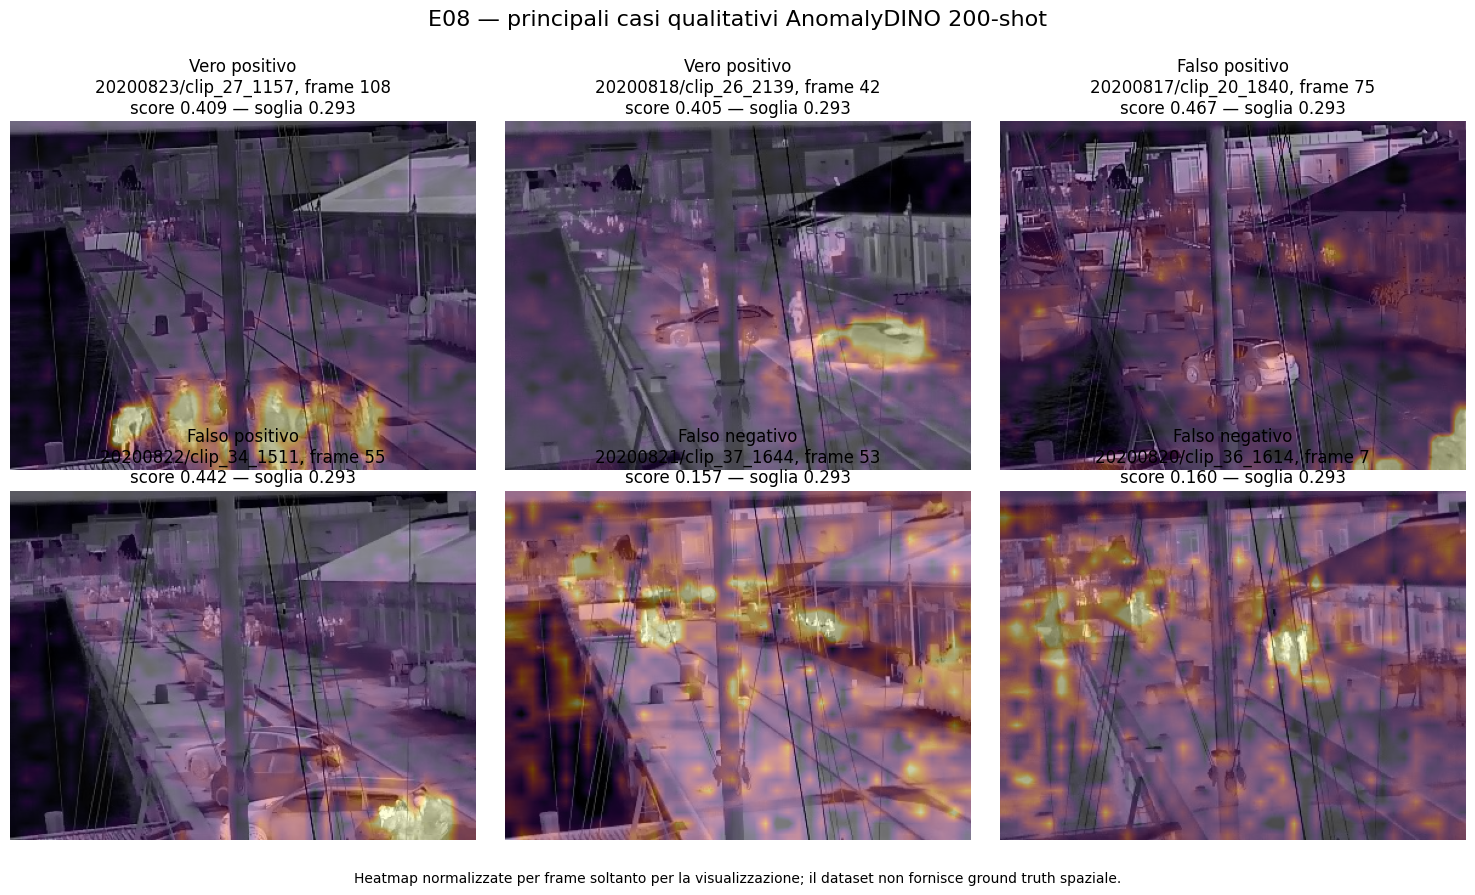

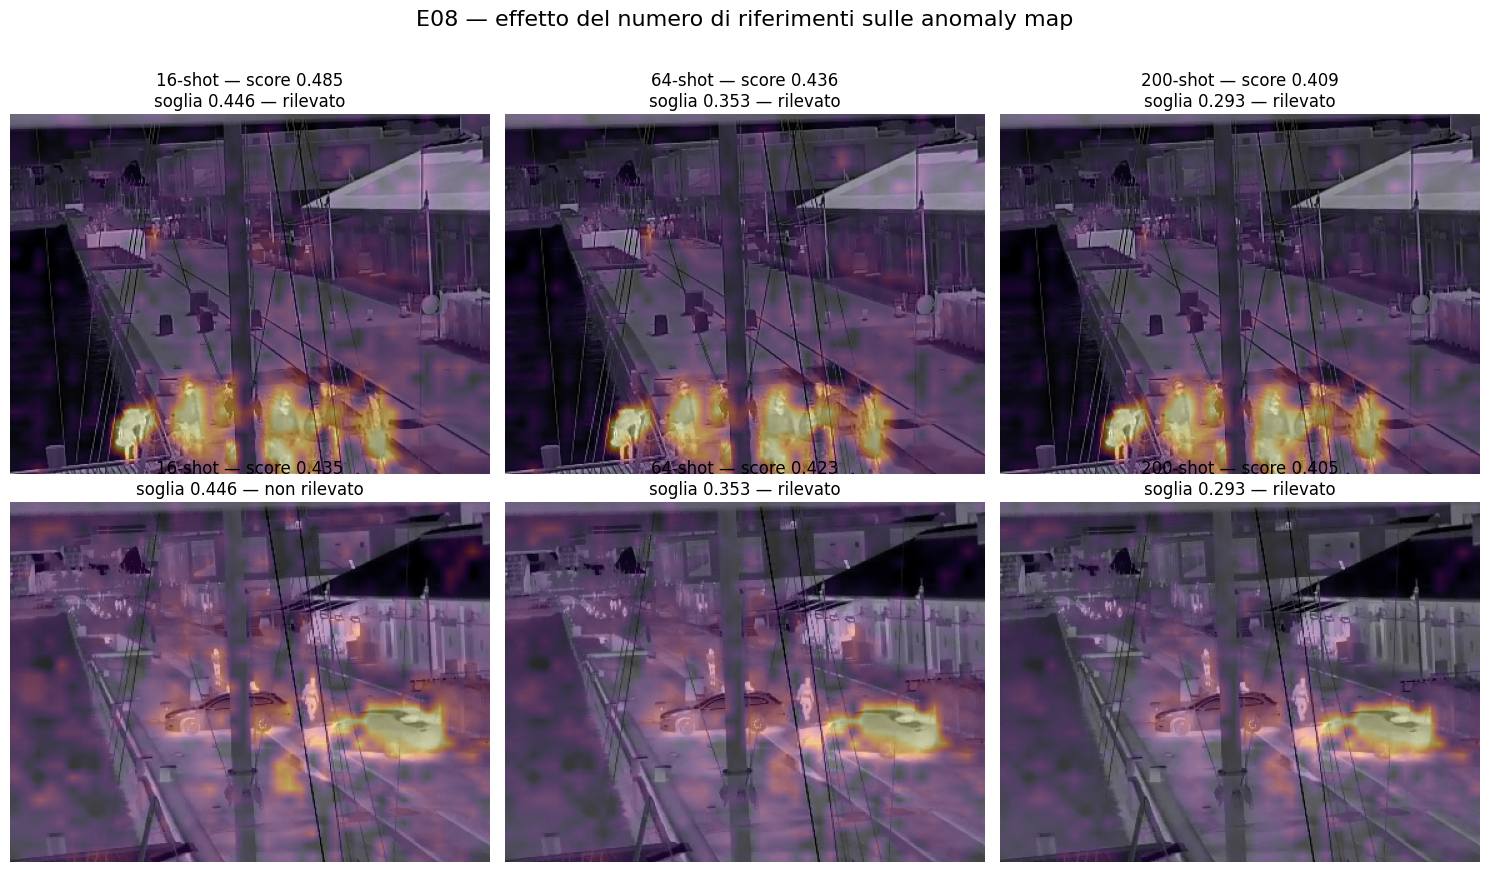

ZIP creato: /kaggle/working/E08_qualitative_checkpoint.zip
SHA-256: 86be09072a53af1ddb599eea1a943d5d33f64bc4b6e2e54af26fb82a9f0b1a18


/kaggle/working/E08_qualitative_checkpoint.zip

In [12]:
from pathlib import Path
from PIL import Image
from IPython.display import FileLink, display
import hashlib
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORK = Path("/kaggle/working")

results = pd.read_csv(WORK / "E08_scores.csv")
results["npz_index"] = np.arange(len(results))

archive = np.load(
    WORK / "E08_raw_maps_float16.npz",
    allow_pickle=False,
)

maps = {
    16: archive["maps_16"],
    64: archive["maps_64"],
    200: archive["maps_200"],
}

thresholds = {
    16: 0.44575324207544326,
    64: 0.35331681221723554,
    200: 0.29267933666706075,
}

def distinct_cases(mask, score_column, ascending, count=2):
    return (
        results.loc[mask]
        .sort_values(score_column, ascending=ascending)
        .drop_duplicates(["date", "clip"])
        .head(count)
        .copy()
    )

score_column = "score_200_shot"
prediction_200 = results[score_column] >= thresholds[200]

true_positives = distinct_cases(
    (results["label"] == 1) & prediction_200,
    score_column,
    ascending=False,
)

false_positives = distinct_cases(
    (results["label"] == 0) & prediction_200,
    score_column,
    ascending=False,
)

false_negatives = distinct_cases(
    (results["label"] == 1) & ~prediction_200,
    score_column,
    ascending=True,
)

true_positives["case_type"] = "Vero positivo"
false_positives["case_type"] = "Falso positivo"
false_negatives["case_type"] = "Falso negativo"

cases = pd.concat(
    [true_positives, false_positives, false_negatives],
    ignore_index=True,
)

def make_overlay(row, shot):
    image = Image.open(row["path"]).convert("RGB")
    image_array = np.asarray(image, dtype=np.float32) / 255.0

    heatmap = maps[shot][int(row["npz_index"])].astype(np.float32)
    heatmap = np.asarray(
        Image.fromarray(heatmap).resize(
            image.size,
            Image.Resampling.BILINEAR,
        )
    )

    low, high = np.percentile(heatmap, [1, 99])

    if high > low:
        normalized = np.clip(
            (heatmap - low) / (high - low),
            0,
            1,
        )
    else:
        normalized = np.zeros_like(heatmap)

    colored = plt.cm.inferno(normalized)[..., :3]
    return 0.58 * image_array + 0.42 * colored

# Figura TP, FP e FN con il 200-shot
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for axis, (_, row) in zip(axes.flat, cases.iterrows()):
    axis.imshow(make_overlay(row, 200))
    axis.set_title(
        f'{row["case_type"]}\n'
        f'{row["date"]}/{row["clip"]}, frame {row["frame_index"]}\n'
        f'score {row["score_200_shot"]:.3f} — soglia {thresholds[200]:.3f}'
    )
    axis.axis("off")

fig.suptitle(
    "E08 — principali casi qualitativi AnomalyDINO 200-shot",
    fontsize=16,
)
fig.text(
    0.5,
    0.01,
    "Heatmap normalizzate per frame soltanto per la visualizzazione; "
    "il dataset non fornisce ground truth spaziale.",
    ha="center",
)
fig.tight_layout(rect=[0, 0.04, 1, 0.95])

errors_path = WORK / "E08_qualitative_errors_200shot.png"
fig.savefig(errors_path, dpi=180, bbox_inches="tight")
plt.show()

# Confronto 16/64/200-shot sugli stessi due frame
high_anomaly = distinct_cases(
    results["label"] == 1,
    "score_16_shot",
    ascending=False,
    count=1,
)

recovered_mask = (
    (results["label"] == 1)
    & (results["score_16_shot"] < thresholds[16])
    & (results["score_200_shot"] >= thresholds[200])
)

recovered = distinct_cases(
    recovered_mask,
    "score_200_shot",
    ascending=False,
    count=1,
)

if len(recovered) == 0:
    alternatives = results[results["label"] == 1].copy()
    alternatives["relative_gain"] = (
        alternatives["score_200_shot"] / thresholds[200]
        - alternatives["score_16_shot"] / thresholds[16]
    )
    recovered = (
        alternatives.sort_values("relative_gain", ascending=False)
        .drop_duplicates(["date", "clip"])
        .head(1)
    )

comparison_cases = pd.concat(
    [high_anomaly, recovered],
    ignore_index=True,
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row_index, (_, row) in enumerate(comparison_cases.iterrows()):
    for column_index, shot in enumerate([16, 64, 200]):
        axis = axes[row_index, column_index]
        score = row[f"score_{shot}_shot"]
        detected = score >= thresholds[shot]

        axis.imshow(make_overlay(row, shot))
        axis.set_title(
            f"{shot}-shot — score {score:.3f}\n"
            f"soglia {thresholds[shot]:.3f} — "
            f'{"rilevato" if detected else "non rilevato"}'
        )
        axis.axis("off")

    axes[row_index, 0].set_ylabel(
        f'{row["date"]}/{row["clip"]}\nframe {row["frame_index"]}',
        fontsize=11,
    )

fig.suptitle(
    "E08 — effetto del numero di riferimenti sulle anomaly map",
    fontsize=16,
)
fig.tight_layout(rect=[0, 0, 1, 0.95])

comparison_path = WORK / "E08_reference_count_comparison.png"
fig.savefig(comparison_path, dpi=180, bbox_inches="tight")
plt.show()

cases.to_csv(
    WORK / "E08_qualitative_cases.csv",
    index=False,
)

zip_path = WORK / "E08_qualitative_checkpoint.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED,
) as zip_file:
    for path in [
        errors_path,
        comparison_path,
        WORK / "E08_qualitative_cases.csv",
    ]:
        zip_file.write(
            path,
            arcname=f"E08_qualitative/{path.name}",
        )

digest = hashlib.sha256(zip_path.read_bytes()).hexdigest()

print("ZIP creato:", zip_path)
print("SHA-256:", digest)
display(FileLink(str(zip_path)))

In [13]:
# Aumenta lo spazio verticale nelle due figure già create
for path in [
    WORK / "E08_qualitative_errors_200shot.png",
    WORK / "E08_reference_count_comparison.png",
]:
    print(path.name, path.exists())

E08_qualitative_errors_200shot.png True
E08_reference_count_comparison.png True
